# 06 - Pipeline `cnn-finetune` (Optuna-tuned)

Fine-tune an ImageNet backbone at 224px (EfficientNet-B0 / ResNet50). The search tunes backbone, dropout, head LR, discriminative-LR decay, weight decay and loss; the final model uses two-stage fine-tuning (head, then discriminative unfreeze) with EMA.

**Sections:** 0 Setup - 1 Data - 2 Hyperparameter search (Optuna) - 3 Final train - 4 Curves - 5 In-dist eval - 6 OOD preview - 7 Explainability - 8 metrics.json

Training is **Optuna-driven**: a search maximizes val AUC (with pruning), the winner is saved, and the final model is trained on it. Set `TUNE=False` to skip the search and reuse the committed `best_params.json`. Artifacts -> `notebooks/artifacts/cnn-finetune/{models,figures,metrics,tuning}`.

## 0 - Setup

In [1]:
import sys, time, json, gc
from pathlib import Path
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from IPython.display import display
import optuna

_here = Path.cwd()
_nb_dir = _here if (_here / "utils").is_dir() else _here / "notebooks"
if str(_nb_dir) not in sys.path:
    sys.path.insert(0, str(_nb_dir))

from utils import datasets as D, models as M, training as T, metrics as Me, viz as V, explain as E, eda, tuning as TU
from utils.paths import repo_paths, artifact_dirs

optuna.logging.set_verbosity(optuna.logging.WARNING)
torch.manual_seed(42); np.random.seed(42)
torch.backends.cudnn.benchmark = True
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
torch.set_float32_matmul_precision("high")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

PATHS = repo_paths(_nb_dir)
DATA_DIR = PATHS["data"]
AIR_DIR = DATA_DIR / "ai-real-images"
SPLIT_PATH = AIR_DIR / "manifest_split.csv"
TINY_MANIFEST = DATA_DIR / "tiny-genimage" / "manifest_clean.csv"

PIPELINE = "cnn-finetune"
WORKING_SIZE = 224
NORM = "imagenet"
BATCH_SIZE = 96
TUNE = True
N_TRIALS = 12
SEARCH_EPOCHS = 8
STAGE1_EPOCHS = 3
STAGE2_EPOCHS = 12
NUM_WORKERS = 8
dirs = artifact_dirs(PIPELINE)
print("device:", device, "| pipeline:", PIPELINE)

device: cuda | pipeline: cnn-finetune


## (GPU clean)

In [2]:
# Clear the GPU at the very start (frees this process's CUDA cache + reports free VRAM).
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache(); torch.cuda.ipc_collect()
    free_b, total_b = torch.cuda.mem_get_info()
    print(f"GPU cleaned - free {free_b / 1e9:.1f} / {total_b / 1e9:.1f} GB")
else:
    print("CPU mode - nothing to clean")

GPU cleaned - free 11.8 / 12.9 GB


## 1 - Data

In [3]:
loaders = D.make_loaders(SPLIT_PATH, working_size=WORKING_SIZE, batch_size=BATCH_SIZE, num_workers=NUM_WORKERS, norm=NORM)
train_loader, val_loader, test_loader = loaders["train"], loaders["val"], loaders["test"]
mean, std = D.resolve_stats(NORM, AIR_DIR)
split_df = pd.read_csv(SPLIT_PATH); split_df = split_df[split_df["keep"]]
test_df = split_df[split_df["split_final"] == "test"].reset_index(drop=True)
print(f"train {len(train_loader.dataset):,} | val {len(val_loader.dataset):,} | test {len(test_loader.dataset):,}")

train 43,127 | val 4,792 | test 11,963


## 2 - Hyperparameter search (Optuna)

Each trial unfreezes the backbone and fine-tunes with discriminative LRs for a few epochs, reporting val AUC.

In [4]:
SEARCH_SPACE = {
    "backbone": {"type": "categorical", "choices": ["efficientnet_b0", "resnet50"]},
    "p_drop": {"type": "float", "low": 0.1, "high": 0.5},
    "head_lr": {"type": "loguniform", "low": 3e-4, "high": 3e-3},
    "disc_decay": {"type": "float", "low": 0.2, "high": 0.5},
    "weight_decay": {"type": "loguniform", "low": 1e-5, "high": 1e-3},
    "label_smooth": {"type": "float", "low": 0.0, "high": 0.1},
    "loss": {"type": "categorical", "choices": ["bce", "focal"]},
}
DEFAULTS = {"backbone": "efficientnet_b0", "p_drop": 0.3, "head_lr": 1e-3, "disc_decay": 0.3, "weight_decay": 1e-4, "label_smooth": 0.05, "loss": "bce"}

def objective(trial):
    p = {
        "backbone": trial.suggest_categorical("backbone", ["efficientnet_b0", "resnet50"]),
        "p_drop": trial.suggest_float("p_drop", 0.1, 0.5),
        "head_lr": trial.suggest_float("head_lr", 3e-4, 3e-3, log=True),
        "disc_decay": trial.suggest_float("disc_decay", 0.2, 0.5),
        "weight_decay": trial.suggest_float("weight_decay", 1e-5, 1e-3, log=True),
        "label_smooth": trial.suggest_float("label_smooth", 0.0, 0.1),
        "loss": trial.suggest_categorical("loss", ["bce", "focal"]),
    }
    gamma = trial.suggest_float("focal_gamma", 1.0, 3.0) if p["loss"] == "focal" else 2.0
    model = M.build_cnn_finetune(p["backbone"], pretrained=True, p_drop=p["p_drop"]).to(device, memory_format=torch.channels_last)
    M.unfreeze_all(model)
    groups = M.build_discriminative_param_groups(model, p["backbone"], head_lr=p["head_lr"], decay=p["disc_decay"], weight_decay=p["weight_decay"])
    opt = torch.optim.AdamW(groups); loss_fn = TU.make_loss(p["loss"], gamma)
    spe = len(train_loader); sched = T.build_cosine_with_warmup(opt, total_steps=SEARCH_EPOCHS * spe, warmup_steps=spe)
    best = 0.0
    try:
        for ep in range(SEARCH_EPOCHS):
            T.train_one_epoch(model, train_loader, opt, loss_fn, device, scheduler=sched, label_smooth=p["label_smooth"])
            yv, pv, _ = T.evaluate(model, val_loader, device); auc = Me.classification_metrics(yv, pv)["auc_roc"]
            best = max(best, auc); TU.report_or_prune(trial, ep, auc)
        return best
    finally:
        TU.cleanup(model, opt)

def _cb(study, trial):
    v = trial.value if trial.value is not None else float("nan")
    print(f"  trial {trial.number:02d}: {trial.state.name:8s} value={v:.4f}")

TUNE_SUMMARY = {"tuned": bool(TUNE), "search_space": SEARCH_SPACE}
if TUNE:
    study = TU.make_study(PIPELINE, dirs["models"].parent / "tuning")
    study.optimize(objective, n_trials=N_TRIALS, callbacks=[_cb], gc_after_trial=True)
    TU.save_study_artifacts(study, SEARCH_SPACE, dirs["figures"], dirs["metrics"])
    best = {**DEFAULTS, **study.best_params}
    TUNE_SUMMARY.update(n_trials=len(study.trials), best_val_auc=float(study.best_value), best_params=best)
    print("\nBEST:", best, "| val_auc", round(study.best_value, 4))
else:
    best = TU.load_best_params(dirs["metrics"], DEFAULTS)
    TUNE_SUMMARY["best_params"] = best
    print("TUNE off -> using", best)

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

C:\Users\user\AppData\Roaming\Python\Python312\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\user\.cache\huggingface\hub\models--timm--resnet50.a1_in1k. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


  trial 00: COMPLETE value=0.9881


  trial 01: COMPLETE value=0.9918


  trial 02: COMPLETE value=0.9873


...

  trial 10: COMPLETE value=0.9922


  trial 11: PRUNED   value=0.9853


C:\Users\user\Desktop\MSc - AI\Εξάμηνο 2ο\Βαθιά Μάθηση\deepfake-detection\notebooks\utils\tuning.py:143: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  ax = fn(study)
C:\Users\user\Desktop\MSc - AI\Εξάμηνο 2ο\Βαθιά Μάθηση\deepfake-detection\notebooks\utils\tuning.py:143: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  ax = fn(study)


C:\Users\user\Desktop\MSc - AI\Εξάμηνο 2ο\Βαθιά Μάθηση\deepfake-detection\notebooks\utils\tuning.py:143: ExperimentalWarning: optuna.visualization.matplotlib._parallel_coordinate.plot_parallel_coordinate is experimental (supported from v2.2.0). The interface can change in the future.
  ax = fn(study)
C:\Users\user\AppData\Roaming\Python\Python312\site-packages\optuna\visualization\matplotlib\_parallel_coordinate.py:115: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax2.set_ylim(dim.range[0], dim.range[1])



BEST: {'backbone': 'efficientnet_b0', 'p_drop': 0.4730073038926608, 'head_lr': 0.0014316113516618027, 'disc_decay': 0.3336613993697719, 'weight_decay': 1.0692354501518688e-05, 'label_smooth': 0.060089817896396655, 'loss': 'focal', 'focal_gamma': 2.9407547475576137} | val_auc 0.9922


## 3 - Final train (best params, two-stage + EMA)

In [5]:
BACKBONE = best["backbone"]
model = M.build_cnn_finetune(BACKBONE, pretrained=True, p_drop=best["p_drop"]).to(device, memory_format=torch.channels_last)
loss_fn = TU.make_loss(best["loss"], best.get("focal_gamma", 2.0))
history = {"train_loss": [], "val_loss": [], "val_auc": [], "val_acc": []}
ckpt_path = dirs["models"] / f"best_{BACKBONE}.pt"

# Stage 1 - head only
M.freeze_backbone(model)
opt1 = torch.optim.AdamW([p for p in model.parameters() if p.requires_grad], lr=best["head_lr"], weight_decay=best["weight_decay"])
spe = len(train_loader); sched1 = T.build_cosine_with_warmup(opt1, total_steps=STAGE1_EPOCHS * spe, warmup_steps=max(1, spe // 2))
for epoch in range(STAGE1_EPOCHS):
    tr = T.train_one_epoch(model, train_loader, opt1, loss_fn, device, scheduler=sched1, label_smooth=best["label_smooth"])
    yv, pv, vloss = T.evaluate(model, val_loader, device, loss_fn); vm = Me.classification_metrics(yv, pv)
    history["train_loss"].append(tr["loss"]); history["val_loss"].append(vloss); history["val_auc"].append(vm["auc_roc"]); history["val_acc"].append(vm["accuracy"])
    print(f"[S1] {epoch+1}/{STAGE1_EPOCHS} val_auc {vm['auc_roc']:.4f}")

# Stage 2 - discriminative unfreeze + EMA
M.unfreeze_all(model)
groups = M.build_discriminative_param_groups(model, BACKBONE, head_lr=best["head_lr"], decay=best["disc_decay"], weight_decay=best["weight_decay"])
opt2 = torch.optim.AdamW(groups); sched2 = T.build_cosine_with_warmup(opt2, total_steps=STAGE2_EPOCHS * spe, warmup_steps=spe)
ema = T.EMA(model, decay=0.999); stopper = T.EarlyStopper(mode="max", patience=7, min_delta=1e-3); best_auc = -1.0
for epoch in range(STAGE2_EPOCHS):
    t0 = time.time()
    tr = T.train_one_epoch(model, train_loader, opt2, loss_fn, device, scheduler=sched2, ema=ema, label_smooth=best["label_smooth"])
    ema.copy_to(model); yv, pv, vloss = T.evaluate(model, val_loader, device, loss_fn); ema.restore(model)
    vm = Me.classification_metrics(yv, pv)
    history["train_loss"].append(tr["loss"]); history["val_loss"].append(vloss); history["val_auc"].append(vm["auc_roc"]); history["val_acc"].append(vm["accuracy"])
    improved, stop = stopper.step(vm["auc_roc"])
    if improved:
        best_auc = vm["auc_roc"]; T.save_weights(ckpt_path, ema.state_dict(), meta={"pipeline": PIPELINE, "backbone": BACKBONE, "kind": "full_finetuned_ema", **best})
    print(f"[S2] {epoch+1}/{STAGE2_EPOCHS} val_auc(ema) {vm['auc_roc']:.4f} | {time.time()-t0:.0f}s{'  *best' if improved else ''}")
    if stop:
        print("early stopping"); break

[S1] 1/3 val_auc 0.7216


[S1] 2/3 val_auc 0.7820


[S1] 3/3 val_auc 0.7925


[S2] 1/12 val_auc(ema) 0.8580 | 69s  *best


[S2] 2/12 val_auc(ema) 0.6238 | 69s


...

[S2] 8/12 val_auc(ema) 0.9914 | 69s


[S2] 9/12 val_auc(ema) 0.9917 | 69s  *best


[S2] 10/12 val_auc(ema) 0.9919 | 69s


[S2] 11/12 val_auc(ema) 0.9922 | 69s


[S2] 12/12 val_auc(ema) 0.9924 | 69s


## 4 - Training curves

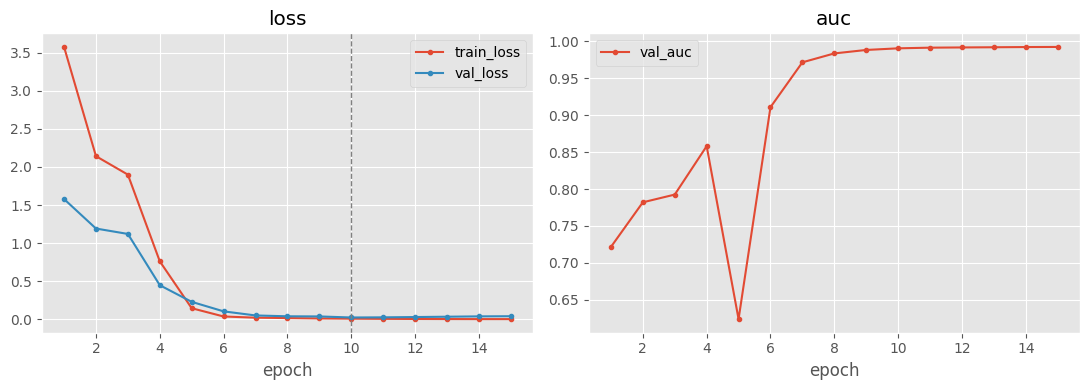

In [6]:
V.plot_training_curves(history).savefig(dirs["figures"] / "training_curves.png", dpi=150, bbox_inches="tight"); plt.show()

## 5 - In-distribution evaluation

tuned threshold: 0.582


,threshold,n,n_fake,n_real,accuracy,f1_macro,precision,recall,auc_roc,pr_auc,mcc,brier
0,0.5,11963,5977,5986,0.955948,0.955939,0.943234,0.970219,0.993045,0.99357,0.91227,0.035693


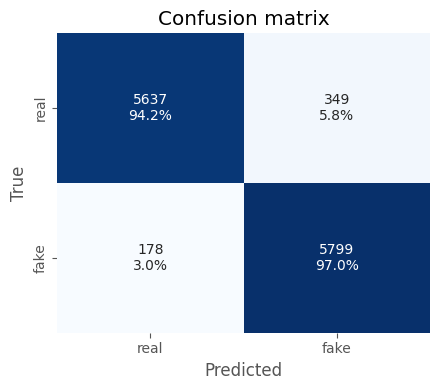

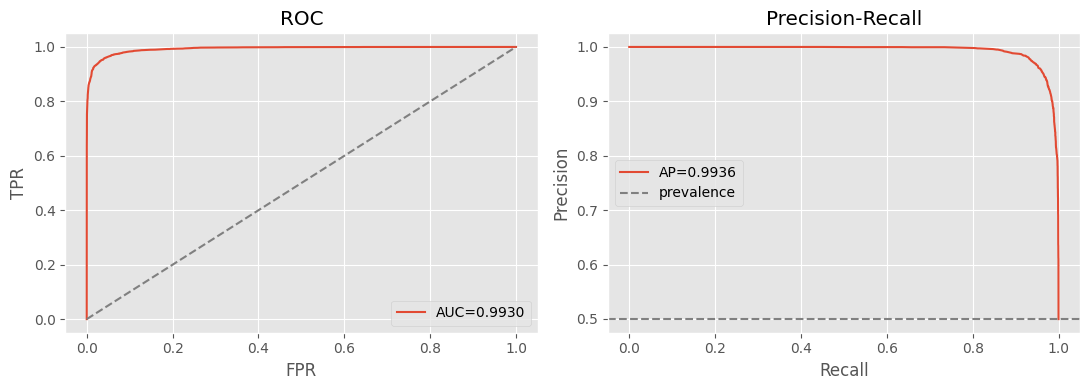

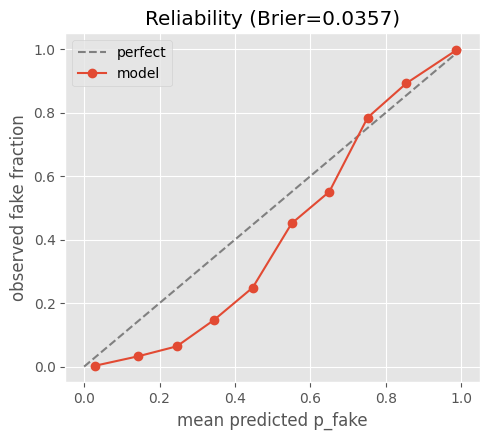

In [7]:
T.load_weights(ckpt_path, model, map_location=device)
yt, pt, _ = T.evaluate(model, test_loader, device)
yv, pv, _ = T.evaluate(model, val_loader, device)
tuned = Me.best_f1_threshold(yv, pv)
m05 = Me.classification_metrics(yt, pt, threshold=0.5)
mtuned = Me.classification_metrics(yt, pt, threshold=tuned["threshold"])
print("tuned threshold:", round(tuned["threshold"], 4)); display(Me.summary_table(m05))
V.plot_confusion(m05["confusion_matrix"]).savefig(dirs["figures"] / "confusion.png", dpi=150, bbox_inches="tight")
V.plot_roc_pr(yt, pt).savefig(dirs["figures"] / "roc_pr.png", dpi=150, bbox_inches="tight")
V.plot_reliability(yt, pt).savefig(dirs["figures"] / "reliability.png", dpi=150, bbox_inches="tight"); plt.show()

## 6 - Cross-generator (OOD) preview

,generator,accuracy,n
0,adm,0.598800,5000
1,biggan,0.436400,5000
2,glide,0.560400,5000
3,midjourney,0.739748,4999
4,sdv5,0.609122,4999
5,vqdm,0.358000,5000
6,wukong,0.643000,5000


overall OOD accuracy: 0.5636  (in-dist 0.9559)


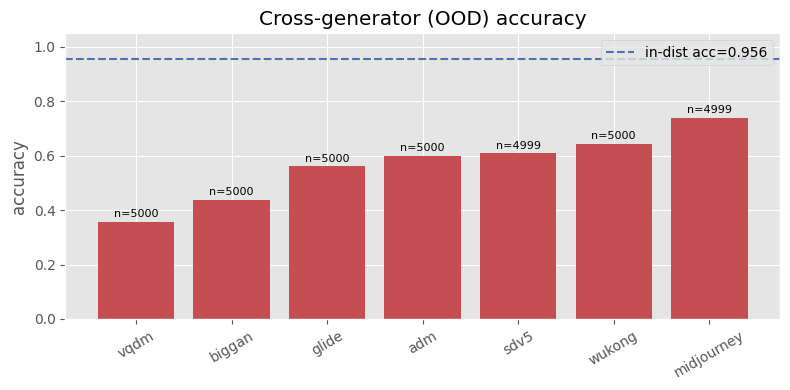

In [8]:
GEN_MAP = {
    "imagenet_ai_0419_biggan": "biggan", "imagenet_ai_0419_vqdm": "vqdm",
    "imagenet_ai_0424_sdv5": "sdv5", "imagenet_ai_0424_wukong": "wukong",
    "imagenet_ai_0508_adm": "adm", "imagenet_glide": "glide", "imagenet_midjourney": "midjourney",
}
ood_loader, ood_df = D.make_ood_loader(TINY_MANIFEST, WORKING_SIZE, BATCH_SIZE, mean, std, num_workers=NUM_WORKERS)
yo, po, _ = T.evaluate(model, ood_loader, device)
ood_df = ood_df.assign(p_fake=po, y_true=yo)
ood_df["y_pred"] = (ood_df["p_fake"] >= 0.5).astype(int)
ood_df["generator"] = ood_df["source"].map(GEN_MAP).fillna(ood_df["source"])
per_gen = pd.DataFrame([{"generator": g, "accuracy": float((d["y_pred"] == d["y_true"]).mean()), "n": int(len(d))} for g, d in ood_df.groupby("generator")])
overall_ood = float((ood_df["y_pred"] == ood_df["y_true"]).mean())
display(per_gen); print(f"overall OOD accuracy: {overall_ood:.4f}  (in-dist {m05['accuracy']:.4f})")
V.plot_per_generator_bar(per_gen, ref_acc=m05["accuracy"]).savefig(dirs["figures"] / "ood_per_generator.png", dpi=150, bbox_inches="tight"); plt.show()

## 7 - Explainability (Grad-CAM)

C:\Users\user\AppData\Local\Temp\ipykernel_15180\1748046637.py:6: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\torch\csrc\utils\tensor_numpy.cpp:212.)
  arr = eda.read_rgb(ex["filepath"]); xt = eval_tf(torch.from_numpy(arr).permute(2, 0, 1)); x = xt.unsqueeze(0).to(device)


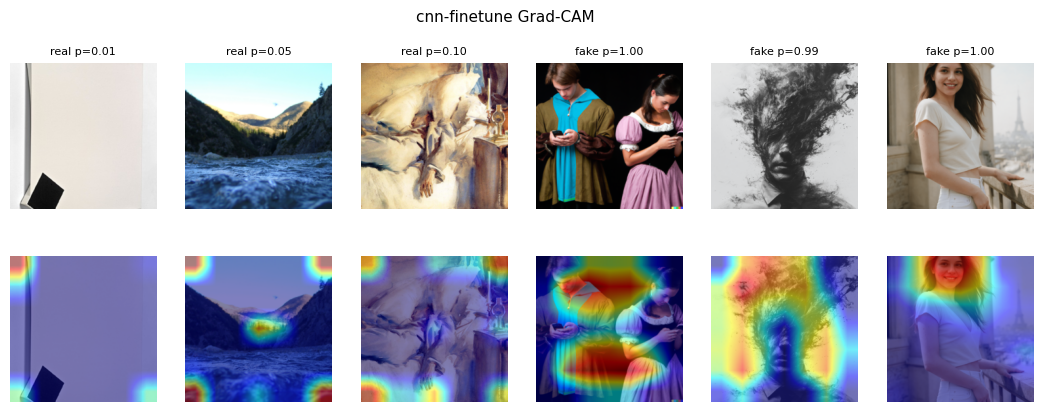

In [9]:
eval_tf = D.build_eval_tf(WORKING_SIZE, mean, std)
target_layers = [model.layer4[-1]] if "resnet" in BACKBONE else [model.conv_head]
examples = E.pick_examples(test_df, n_per_class=3, seed=0)
fig, axes = plt.subplots(2, len(examples), figsize=(2.2 * len(examples), 4.6)); model.eval()
for j, ex in enumerate(examples):
    arr = eda.read_rgb(ex["filepath"]); xt = eval_tf(torch.from_numpy(arr).permute(2, 0, 1)); x = xt.unsqueeze(0).to(device)
    rgb = D.denormalize(xt, mean, std).permute(1, 2, 0).numpy()
    with torch.no_grad():
        p = torch.sigmoid(model(x)).item()
    overlay = E.gradcam_overlay(model, target_layers, x, rgb)
    axes[0, j].imshow(rgb); axes[0, j].axis("off"); axes[0, j].set_title(f"{ex['label']} p={p:.2f}", fontsize=8)
    axes[1, j].imshow(overlay); axes[1, j].axis("off")
fig.suptitle("cnn-finetune Grad-CAM", fontsize=11)
fig.savefig(dirs["figures"] / "gradcam.png", dpi=150, bbox_inches="tight"); plt.show()

## 8 - Save metrics.json

In [10]:
record = {
    "pipeline": PIPELINE, "created": datetime.now(timezone.utc).isoformat(timespec="seconds"),
    "working_size": WORKING_SIZE, "normalization": NORM,
    "dataset": {"in_distribution": "ai-real-images", "ood": "tiny-genimage"},
    "threshold_default": 0.5, "threshold_tuned": tuned["threshold"],
    "in_distribution": {"at_0.5": m05, "at_tuned": mtuned},
    "ood": {"overall_accuracy": overall_ood, "per_generator": {r.generator: {"accuracy": r.accuracy, "n": r.n} for r in per_gen.itertuples()}, "preview": True},
    "tuning": TUNE_SUMMARY,
    "backbone": BACKBONE,
    "figures": {k: f"figures/{k}.png" for k in ['training_curves', 'confusion', 'roc_pr', 'reliability', 'ood_per_generator', 'gradcam']},
}
Me.save_metrics(record, dirs["metrics"] / "metrics.json")
print("saved", dirs["metrics"] / "metrics.json")

saved C:\Users\user\Desktop\MSc - AI\Εξάμηνο 2ο\Βαθιά Μάθηση\deepfake-detection\notebooks\artifacts\cnn-finetune\metrics\metrics.json
